# NHL Playoff Predictor Analysis

This notebook answers two questions:

1. **How well does a team's regular-season record predict whether they win a playoff series?**
2. **Which single regular-season stat is the strongest predictor of playoff series wins?**

### Methodology

For each of the 105 playoff series across 7 seasons (2017–18 through 2023–24), we pair the two teams' regular-season stats and record which team won the series. We then measure how often the "better" team by each stat actually won.

Each stat is evaluated on three metrics:
- **Accuracy** — the percentage of series where the team with the better stat won. 50% is a coin flip; anything above that is predictive signal.
- **Correlation (r)** — point-biserial correlation between the stat differential and the series outcome. Positive means the better-stat team wins more often; negative means the opposite. Values near 0 mean the stat has little to no relationship with the outcome.
- **AUC** — area under the ROC curve from a logistic regression using only that one stat. 0.5 is random; 1.0 is perfect. This captures not just *whether* the better-stat team wins, but *how much* the size of the gap matters.

**A note on head-to-head:** We also include each pair's regular-season record *directly against each other* (`h2h_wins`) as a separate stat, to test whether specific matchup history predicts playoff outcomes better than overall record.

In [13]:
import sys
sys.path.insert(0, '../scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from predictor_analysis import load_matchups, analyze, STAT_LABELS, LOWER_IS_BETTER

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

df = load_matchups()
print(f"{len(df)} series across {df['season'].nunique()} seasons")
df.head()

105 series across 7 seasons


,season,round,series_letter,team_hi,team_lo,winner,hi_won,series_result,points_hi,points_lo,...,goals_for_pg_hi,goals_for_pg_lo,goals_for_pg_diff,goals_against_pg_hi,goals_against_pg_lo,goals_against_pg_diff,h2h_gp,h2h_wins_hi,h2h_wins_lo,h2h_wins_diff
0,20172018,1,A,TBL,NJD,TBL,1,4-1,113,97,...,3.609756,3.024390,0.585366,2.878049,2.975610,-0.097561,3,0,3,-3
1,20172018,1,B,BOS,TOR,BOS,1,4-3,112,105,...,3.292683,3.378049,-0.085366,2.609756,2.829268,-0.219512,4,1,3,-2
2,20172018,1,C,WSH,CBJ,WSH,1,4-2,105,97,...,3.158537,2.951220,0.207317,2.914634,2.804878,0.109756,4,3,1,2
3,20172018,1,D,PIT,PHI,PIT,1,4-2,100,98,...,3.317073,3.060976,0.256098,3.048780,2.963415,0.085366,4,4,0,4
4,20172018,1,E,NSH,COL,NSH,1,4-2,117,95,...,3.256098,3.134146,0.121951,2.573171,2.890244,-0.317073,4,4,0,4


## Load data

Loads `playoff_matchups.csv` — one row per playoff series. Each row contains both teams' regular-season stats, their head-to-head record, and which team won the series.

## Does the better regular-season team win?

A first-pass look using points as the proxy for "better team." In each series, one team had more regular-season points (the higher seed) — how often did they win?

Round 1 and Round 4 (Finals) tend to show the strongest signal, as the point differential between opponents is largest. Rounds 2 and 3 tend to be closer matchups where upsets are more common.

## Full predictor leaderboard

Ranks every stat by accuracy, correlation, and AUC. The gradient shading makes it easy to spot which stats sit at the top vs. bottom.

**What to look for:**
- Stats with similar accuracy scores are clustered together — this suggests they're capturing largely the same underlying signal (team quality)
- `h2h_wins` at the bottom tells you that how teams matched up *against each other specifically* during the regular season is the weakest predictor of all

## Visual comparison: accuracy, correlation, and AUC

Three panels, one for each metric. The red dashed line in each panel marks the baseline — 50% accuracy, r=0 correlation, or AUC=0.5 — representing a stat with zero predictive power.

**Key takeaways:**
- All the top stats cluster tightly between 60–62% accuracy. No single stat is dramatically better than the others — they're all capturing the same general idea of "better regular season team"
- The **correlation panel** is the most revealing for head-to-head: `h2h_wins` has a *negative* r value (red bar), meaning teams that dominated their opponent in the regular season head-to-head matchups actually win the playoff series *slightly less often*. This is a weak effect but a consistent one across the dataset
- The **AUC panel** shows that `wins` and `win_pct` are slightly better at using the *size* of the gap (not just the direction) to separate winners from losers

## Best predictor: scatter plot by round

Each dot is one playoff series. The x-axis shows how much better (or worse) the higher-seed team was by the best stat — positive values mean the higher-seed had the better stat. The y-axis is just the outcome: did the higher-seed win (1) or lose (0)?

A slight vertical jitter is added so overlapping points are visible.

**What a strong predictor would look like:** dots concentrated in the top-right (higher-seed was better *and* won) and bottom-left (lower-seed was better *and* won). The more mixed the scatter, the weaker the signal.

## Year-over-year consistency

If the best stat is a genuine signal and not a fluke of the dataset, it should hold up across individual seasons rather than being driven by one or two outlier years.

Each bar shows the prediction accuracy for that season alone. The red dashed line is the 50% coin-flip baseline. Seasons that fall below it are years where the lower-stat team actually won more series — a reminder that the playoffs introduce enough variance that no regular-season stat is reliable in a small sample.

In [14]:
# How often does the higher-points team win each round?
round_summary = (
    df.groupby('round')['hi_won']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'hi_team_win_rate', 'count': 'n_series'})
    .reset_index()
)
round_summary['hi_team_win_rate'] = round_summary['hi_team_win_rate'].map('{:.1%}'.format)
print("Higher regular-season points team win rate by round:")
round_summary

Higher regular-season points team win rate by round:


,round,hi_team_win_rate,n_series
0,1,67.9%,56
1,2,50.0%,28
2,3,35.7%,14
3,4,71.4%,7


In [15]:
# Full predictor leaderboard
results = analyze(df)
results[['label', 'accuracy', 'correlation', 'auc', 'n_series']].style \
    .format({'accuracy': '{:.1%}', 'correlation': '{:.3f}', 'auc': '{:.3f}'}) \
    .background_gradient(subset=['accuracy', 'auc'], cmap='Blues') \
    .set_caption('Regular-season stat predictive power for playoff series wins')

,label,accuracy,correlation,auc,n_series
0,Goal Differential,61.5%,0.123,0.590,105
1,Wins,61.2%,0.124,0.644,105
2,Win %,61.2%,0.096,0.631,105
3,Points,60.8%,0.108,0.630,105
4,Points %,60.8%,0.088,0.610,105
5,Goals Against / Game,56.7%,0.099,0.467,105
6,h2h_wins,55.0%,-0.056,0.520,105
7,Goals For / Game,54.3%,0.013,0.425,105


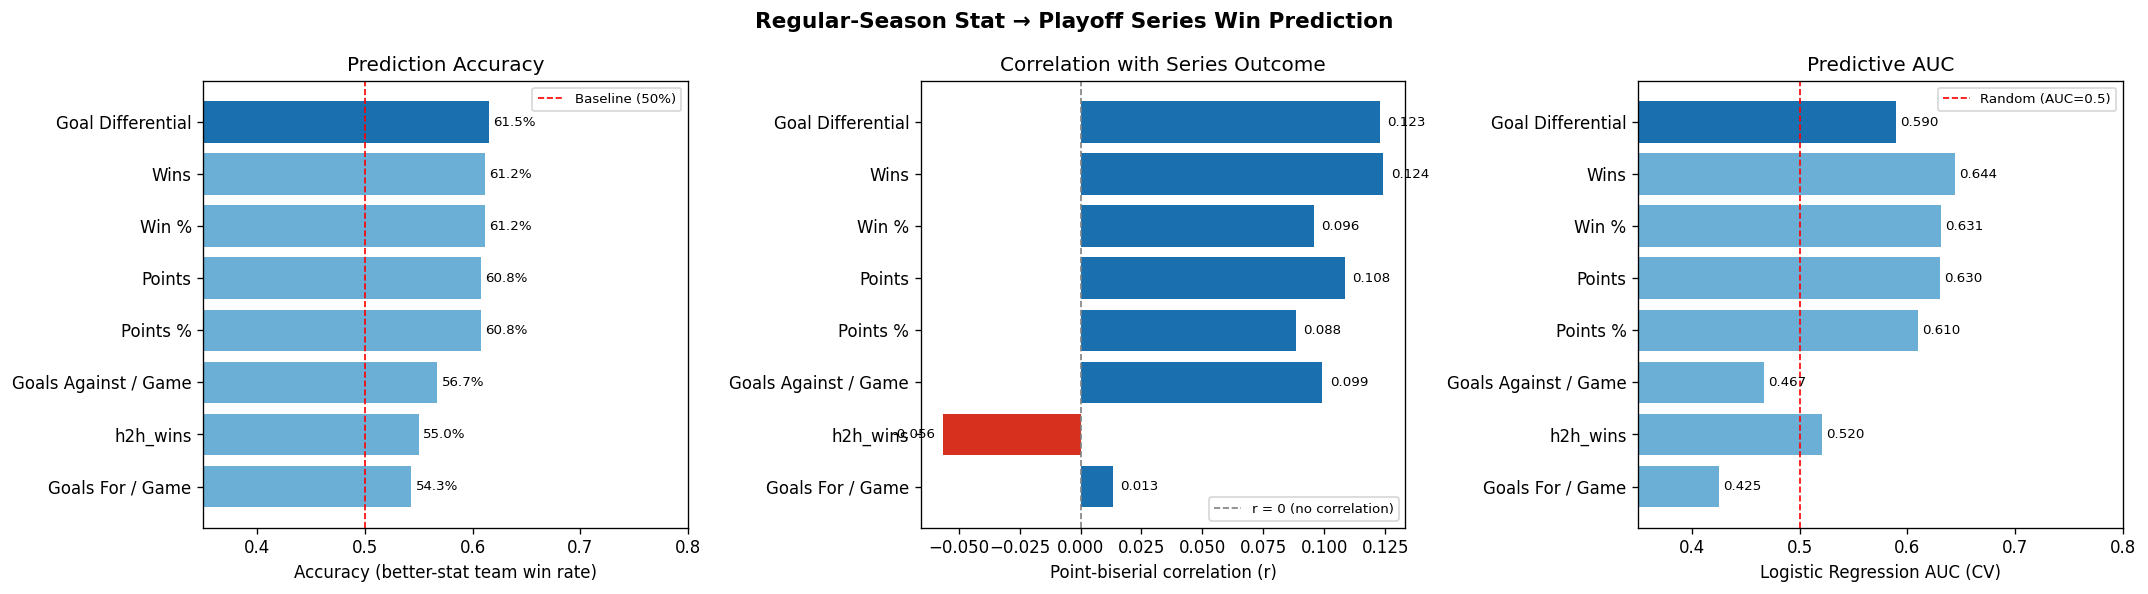

In [16]:
# Three-panel chart: accuracy, correlation (r), and AUC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regular-Season Stat → Playoff Series Win Prediction', fontsize=13, fontweight='bold')

colors = ['#1a6faf' if i == 0 else '#6baed6' for i in range(len(results))]

# Accuracy
ax = axes[0]
bars = ax.barh(results['label'][::-1], results['accuracy'][::-1], color=colors[::-1])
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Baseline (50%)')
ax.set_xlabel('Accuracy (better-stat team win rate)')
ax.set_title('Prediction Accuracy')
ax.set_xlim(0.35, 0.80)
ax.legend(fontsize=8)
for bar, val in zip(bars, results['accuracy'][::-1]):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=8)

# Correlation (r) — can be negative, centre on 0
ax = axes[1]
corr_vals = results['correlation'][::-1]
bar_colors = ['#1a6faf' if v >= 0 else '#d7301f' for v in corr_vals]
bars = ax.barh(results['label'][::-1], corr_vals, color=bar_colors)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='r = 0 (no correlation)')
ax.set_xlabel('Point-biserial correlation (r)')
ax.set_title('Correlation with Series Outcome')
ax.legend(fontsize=8)
for bar, val in zip(bars, corr_vals):
    x = bar.get_width() + 0.003 if val >= 0 else bar.get_width() - 0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=8)

# AUC
ax = axes[2]
bars = ax.barh(results['label'][::-1], results['auc'][::-1], color=colors[::-1])
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('Logistic Regression AUC (CV)')
ax.set_title('Predictive AUC')
ax.set_xlim(0.35, 0.80)
ax.legend(fontsize=8)
for bar, val in zip(bars, results['auc'][::-1]):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

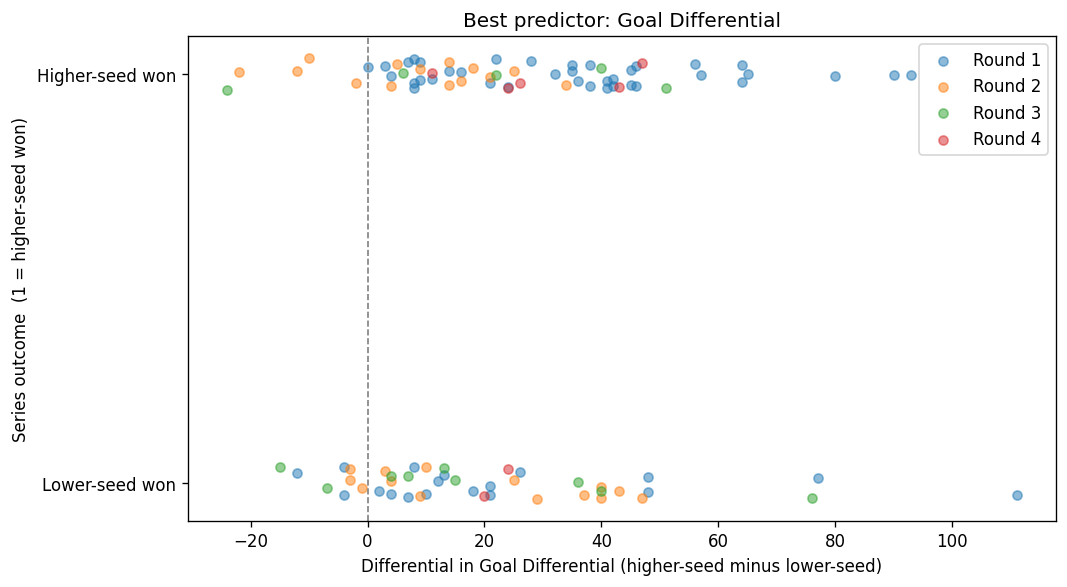

Best predictor: Goal Differential
Accuracy: 61.5%  |  AUC: 0.590  |  r = 0.123


In [17]:
# Scatter: best stat differential vs outcome, coloured by round
best_stat = results.iloc[0]['stat']
best_label = results.iloc[0]['label']
diff_col = f'{best_stat}_diff'

plot_df = df[[diff_col, 'hi_won', 'round', 'season']].dropna()
if best_stat in LOWER_IS_BETTER:
    plot_df[diff_col] = -plot_df[diff_col]

fig, ax = plt.subplots(figsize=(9, 5))
for rnd, grp in plot_df.groupby('round'):
    jitter = np.random.uniform(-0.04, 0.04, len(grp))
    ax.scatter(grp[diff_col], grp['hi_won'] + jitter, alpha=0.5, label=f'Round {rnd}', s=30)

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel(f'Differential in {best_label} (higher-seed minus lower-seed)')
ax.set_ylabel('Series outcome  (1 = higher-seed won)')
ax.set_title(f'Best predictor: {best_label}')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Lower-seed won', 'Higher-seed won'])
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best predictor: {best_label}")
print(f"Accuracy: {results.iloc[0]['accuracy']:.1%}  |  AUC: {results.iloc[0]['auc']:.3f}  |  r = {results.iloc[0]['correlation']:.3f}")

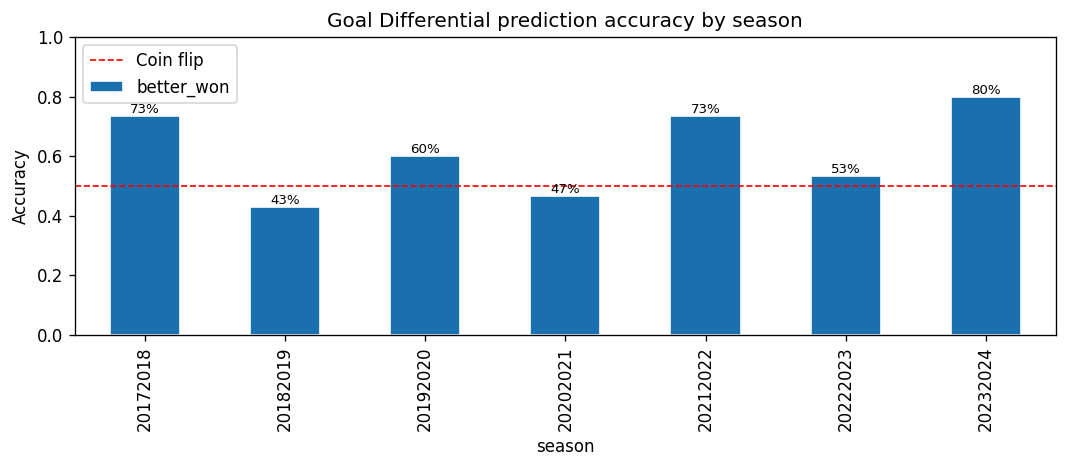

In [18]:
# Per-season consistency: does the best stat hold up year over year?
diff_col = f'{best_stat}_diff'
plot_df = df[[diff_col, 'hi_won', 'season']].dropna().copy()
if best_stat in LOWER_IS_BETTER:
    plot_df[diff_col] = -plot_df[diff_col]

diff = plot_df[diff_col]
plot_df['better_won'] = ((diff > 0) & (plot_df['hi_won'] == 1)) | ((diff < 0) & (plot_df['hi_won'] == 0))
season_acc = plot_df[diff != 0].groupby('season')['better_won'].mean()

ax = season_acc.plot(kind='bar', figsize=(9, 4), color='#1a6faf', edgecolor='white')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Coin flip')
ax.set_title(f'{best_label} prediction accuracy by season')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0%}', (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()